# Geodatenanalyse 2: Hyperparameteroptimierung mit Optuna und Ensemble-Modellierung

Ziel der Übung: Für das Modell aus dem Termin zur Zeitreihenvorhersage von Grundwasserständen sollen Hyperparameter optimiert werden. Wir möchten die optimale die Länge der Inputsequenz sowie der Anzahl der Units im LSTM Layer optimieren. 

Weiterhin minimieren wir den Einfluss der Modellinitialisierung (basierend auf einer Zufallszahl) durch ein Ensemble welches mehrere definierte *random number seeds* nutzt. 

Zunächst nutzen wir Zellen des Notebooks vom letzten Termin.

### set random seed
Um ein reproduzierbares Ergebnis zu erhalten definieren wir zunächst die Startpunkte (seeds) der Zufallszahlengeneratoren von numpy und tensorflow:

In [1]:
#!pip install optuna

In [2]:
#set random seed for reproducability
from numpy.random import seed
seed(42) # this is a randomly chosen number
from tensorflow import random
random.set_seed(42) # this is also a randomly chosen number
print("seeds are set")

import pandas as pd
import numpy as np

from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from keras.layers import Input, LSTM, Dense, Conv1D, MaxPooling1D, Flatten
from keras.models import Model

import matplotlib.pyplot as plt

import optuna

2026-05-18 08:19:01.699360: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 08:19:01.717026: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779092341.735163  616473 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779092341.740623  616473 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779092341.755152  616473 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

seeds are set


### load data
Die (wöchentlichen) Grundwasserdaten befinden sich in der Datei: **GW-Data.csv**  
Die meteorologischen Inputdaten in der Datei: **Climate-Data.csv**

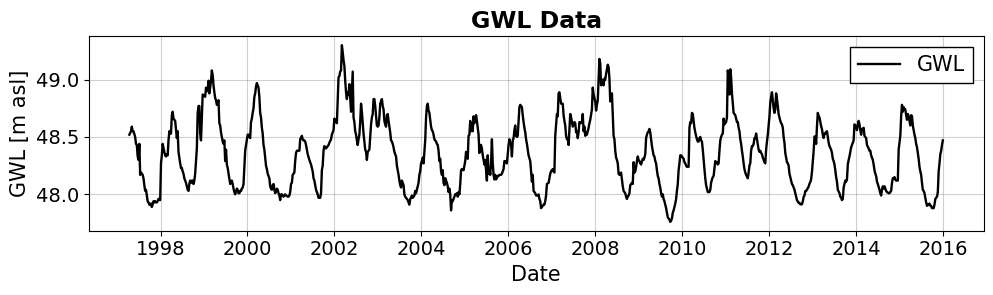

,GWL,P,rH,T,Tsin
Date,,,,,
1997-04-14,48.520,1.203046,62.731979,6.593939,-1.439494
1997-04-21,48.535,0.864522,61.926402,4.493416,-0.347873
1997-04-28,48.550,7.486455,62.071464,9.000969,0.748794
1997-05-05,48.590,30.453424,80.260318,11.661238,1.834601
1997-05-12,48.550,15.360879,71.335400,10.898702,2.893801


In [3]:

GWData = pd.read_csv('./GW-Data.csv',
                     parse_dates=['Date'], # This is used to recognise times as dates
                     index_col=0, # defines which column of the read data is to serve as the index for the DataFrame
                     dayfirst = True,  #defines the date format  
                     decimal = '.', sep=',') #Specifies which separators are used in the file

ClimateData = pd.read_csv('Climate-Data.csv', 
                          parse_dates=['Date'],index_col=0,dayfirst = True,
                          decimal = '.', sep=',')

# Merge Dataframes
data = pd.merge(GWData, ClimateData, how='inner', left_index = True, right_index = True)


#plot GWL data
plt.figure(figsize=(10,3))
plt.plot(data.index,data['GWL'], 'k', label ="GWL", linewidth = 1.7)
plt.title("GWL Data", size=17,fontweight = 'bold')
plt.ylabel('GWL [m asl]', size=15)
plt.xlabel('Date',size=15)
plt.legend(fontsize=15,loc='upper right',fancybox = False, framealpha = 1, edgecolor = 'k')
plt.tight_layout()
plt.grid(visible=True, which='major', color='#666666', alpha = 0.3, linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#inspect the data
data.head()

Der DataFrame setzt sich nun zusammen aus der Indexspalte **Date**, dem Grundwasserstand **GWL**, Niederschlag **P**, relativer Feuchte **rH**, Temperatur **T** und einem geglätteten Temperatursignal **Tsin** (Sinuskurve an T gefittet).  

### Daten in Sequenzen aufteilen:
   
Wir definieren wir eine Funktion die genau das für uns erledigt und die wir immer wieder verwenden können: *make_sequences*    

Diese können wir nachher mit folgender Zeile aufrufen:  
*X,Y = make_sequences(data, n_steps_in)*

Inhaltlich passiert folgendes:

Aus einer Zeitreihe aus Inputdaten X und Zieldaten Y:  
    
    XXXXXXXXXXXXXXX  
    YYYYYYYYYYYYYYY  

werden kleine Schnipsel die jeder Inputsequenz der Länge *n_steps_in* (hier = 4) ein Zielwert zuordnet

    XXXXY
     XXXXY
      XXXXY
       XXXXY
        XXXXY
         XXXXY
          XXXXY
          ...


In [4]:
def make_sequences(data, seq_length):
#     """
#     data: numpy array with target (Y) in first column and model inputs in following columns
#     n_steps_in: number that defines the sequence length
    
#     Output:
#     X: sequenced model input data
#     Y: sequenced model target data
    
#     function modified after: machinelearningmastery.com
#     """
    
    #sequence the data
    X, Y = list(), list()
    # step over the entire history one time step at a time
    for i in range(len(data)):
        # find the end of this pattern
        end_idx = i + seq_length
        # check if we are beyond the dataset
        if end_idx >= len(data):
            break
        # gather input and output parts of the pattern
        seq_x = data[i:end_idx, 1:]
        seq_y = data[end_idx, 0]
        X.append(seq_x)
        Y.append(seq_y)
        
    return np.array(X), np.array(Y)


### split data (diesmal in 4! Teile)

Bevor wir die Daten in Sequenzen umwandeln, müssen wir aber zunächst noch den bekannten Train-Test-Split durchführen und die Daten anschließend skalieren.

Da wir eine Optimierungsfunktion nutzen und data leakage ins testset vermeiden möchten, brauchen wir diesmal 4 Teile unserer Daten.
  
**Training, Early Stopping (Validation), Optimierungs und Testing**  

Wir nutzen folgende Aufeilung:
* Training: < 2010  
* Early Stopping: 2010
* Optimierung: 2011  
* Test: >= 2012  

In [5]:
val_startdate = pd.to_datetime('01012010', format='%d%m%Y')
opt_startdate = pd.to_datetime('01012011', format='%d%m%Y')
test_startdate = pd.to_datetime('01012012', format='%d%m%Y')

#print dates
print("Start Stopset:\n{}\n\nStart Optset:\n{}\n\nStart Testset:\n{}".format(val_startdate,opt_startdate,test_startdate))

#Here we divide the data, but do not let them overlap(!), this depends on n_steps_in, which we have not yet defined
TrainingData = data[(data.index < val_startdate)] 
StopData = data[(data.index >= val_startdate) & (data.index < opt_startdate)]
OptData = data[(data.index >= opt_startdate) & (data.index < test_startdate)]
TestData = data[(data.index >= test_startdate)] 

Start Stopset:
2010-01-01 00:00:00

Start Optset:
2011-01-01 00:00:00

Start Testset:
2012-01-01 00:00:00


### Optimierung:   
Die Optimierung kann nur auf eine Funktion angewendet werden. Wie bereits angesprochen möchten wir *seq_length* optimieren. Alles was nach der Festlegung dieses Parameters erst durchgeführt werden kann (z.B. die Überlappung der der Daten-Sets) muss also in diese Funktion reingeschrieben werden. 

Mit anderen Worten, wir geben dem Optimierungsalgorithmus eine Funktion die alles tut (Daten bearbeiten, Modell aufbauen trainieren, vorhersagen, evaluieren und eine Metrik ausgeben) was wir wollen, aber in Abhängigkeit des zu optimierenden Parameters *seq_length*.

Eine solche Funktion sieht vereinfacht so aus:

```python
def optfunction(seq_length): 
    #hier [CODE] werden die Daten geteilt, skaliert, das Modell aufgebaut, trainiert und evaluiert etc.
    #[...]
    return MSE # oder irgendeine andere Metrik zur Beurteilung des Modells
```

Die Funktion nimmt verschiedene Inputparameter, baut dann das Modell (inkl. aller dafür notwendigen Schritte) und gibt uns den MSE zurück, den wir optimieren (minimieren) möchten.


In [6]:

def optfunction(seq_length):  
    #%%%%%%%%%%%%%%%%%%%%%%%%%%%
    #Now follow the familiar steps as in the last appointment for time series prediction.
    #%%%%%%%%%%%%%%%%%%%%%%%%%%%
    
    #extend with overlap to be able to fill sequence (seq_length) later                                              
    StopData_ext = pd.concat([TrainingData.iloc[-seq_length:], StopData], axis=0) #takes last steps of TrainingData and combines it with StopData
    OptData_ext = pd.concat([StopData.iloc[-seq_length:], OptData], axis=0) #takes last steps of ValidationData and combines it with OptData
    #The test data is not required here in this function, instead we use the option set for evaluation.
    
    #create scalers and fit to data data (normalize: *_n):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(TrainingData) # fit on training data, scale all other parts afterwards

    scaler_gwl = MinMaxScaler(feature_range=(-1, 1)) 
    scaler_gwl.fit(pd.DataFrame(TrainingData['GWL'])) # fit scaler only on GWL for rescaling later
    
    #scale (transform) data
    TrainingData_n = scaler.transform(TrainingData)
    StopData_ext_n = scaler.transform(StopData_ext)
    OptData_ext_n = scaler.transform(OptData_ext)
    
    #Convert data into sequences:
    X_train,Y_train = make_sequences(np.asarray(TrainingData_n), seq_length)
    X_stop,Y_stop = make_sequences(np.asarray(StopData_ext_n), seq_length)
    X_opt,Y_opt = make_sequences(np.asarray(OptData_ext_n), seq_length)
    
    
    #%%%%%%%%%%%%%%%%%%%%%%%%%%%
    #build and train Model:
    #%%%%%%%%%%%%%%%%%%%%%%%%%%%
    
    #set seed
    seed(42)
    tf.random.set_seed(42)
    
    #build Model
    inp = Input(shape=(seq_length, X_train.shape[2])) 
    lstm = LSTM(32)(inp) 
    dense = Dense(30, activation='relu')(lstm) 
    output = Dense(1, activation='linear')(dense) 
    model = Model(inputs=inp, outputs=output)
    #define optimizer
    Adam = tf.keras.optimizers.Adam(learning_rate=1E-3, epsilon=1E-3, clipnorm=True)
  
    #compile the model
    model.compile(loss='mse', optimizer=Adam, metrics=['mse'])

    #define early stopping callback
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=20, restore_best_weights = True)

    #train the model
    history = model.fit(X_train, Y_train,validation_data=(X_stop, Y_stop), epochs=100, verbose=3,
                        batch_size=32, callbacks=[es])

    #plot training loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(['training loss','validation loss'])
    plt.title('Loss')
    plt.show()
    
    #%%%%%%%%%%%%%%%%%%%%%%%%%%%
    #Test and evaluate on OptData
    #%%%%%%%%%%%%%%%%%%%%%%%%%%%
    
    #Test model with X_opt
    sim = model.predict(X_opt)

    #rescale simulated and observed values
    sim = scaler_gwl.inverse_transform(sim)  # retransform to original scale
    obs = scaler_gwl.inverse_transform(Y_opt.reshape(-1,1))
    
    #Mean Squared Error
    MSE =  np.mean((sim-obs) ** 2)
    
    #Plot Optset Simulation to see something during Optimization
    plt.figure(figsize=(6,4))
    plt.plot(OptData.index, sim, 'r', label ="simulated", linewidth = 1.7)
    plt.plot(OptData.index, obs, 'k', label ="observed", linewidth=1.7,alpha=0.9)

    plt.title("Opt Result",fontweight = 'bold')
    plt.ylabel('GWL [m asl]')
    plt.xlabel('Date')
    plt.legend(fancybox = False, framealpha = 1, edgecolor = 'k')
    plt.tight_layout()
    plt.grid(visible=True, which='major', color='#666666', alpha = 0.3, linestyle='-')
    plt.xticks()
    plt.yticks()
    plt.show()
    
    return MSE


Nun haben wir eine Funktion geschrieben die uns in Abhängigkeit von seq_length ein Modell aufbaut, trainiert und den MSE dafür ausgibt.


Lasst uns nun die eigentliche Optimierung schreiben:


[I 2026-05-18 08:19:09,114] A new study created in memory with name: no-name-3ed4f717-24e3-422c-974f-c02c1aab28b1


Epoch 1/100


2026-05-18 08:19:09.126330: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100


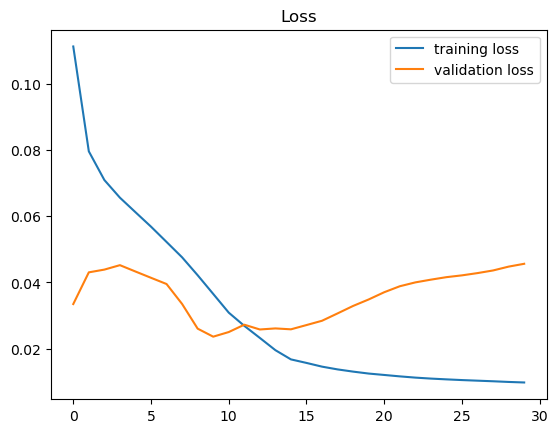

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


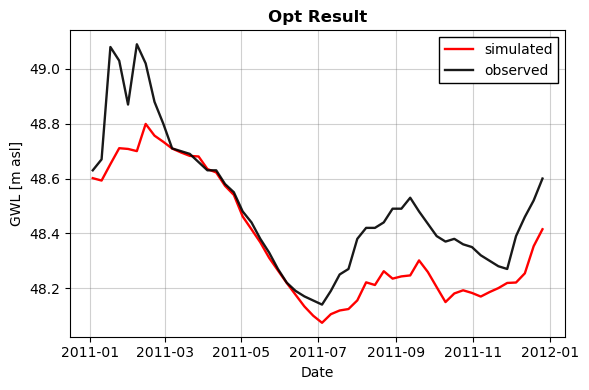

[I 2026-05-18 08:19:32,342] Trial 0 finished with value: 0.026665393286385734 and parameters: {'seq_length': 48}. Best is trial 0 with value: 0.026665393286385734.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100


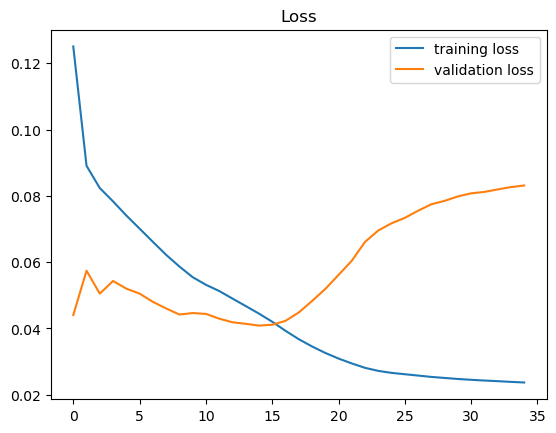

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


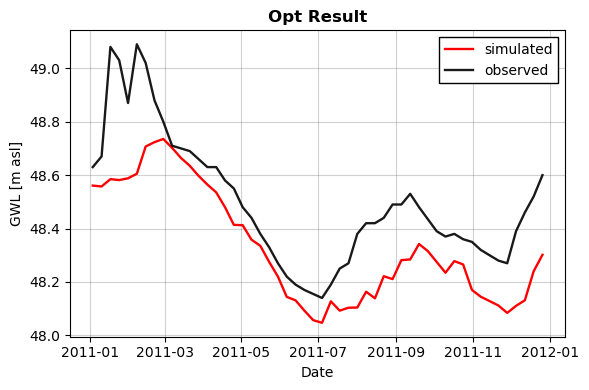

[I 2026-05-18 08:19:50,969] Trial 1 finished with value: 0.04052014191113437 and parameters: {'seq_length': 16}. Best is trial 0 with value: 0.026665393286385734.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100


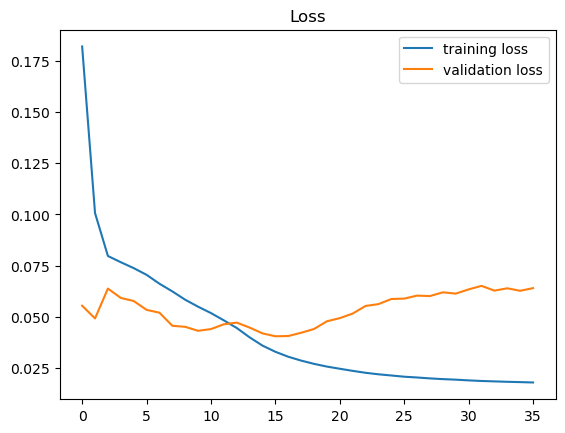

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7727e0346f20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


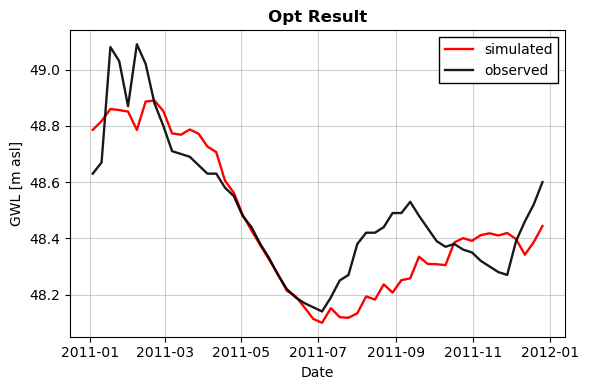

[I 2026-05-18 08:20:13,736] Trial 2 finished with value: 0.017698687694155158 and parameters: {'seq_length': 22}. Best is trial 2 with value: 0.017698687694155158.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100


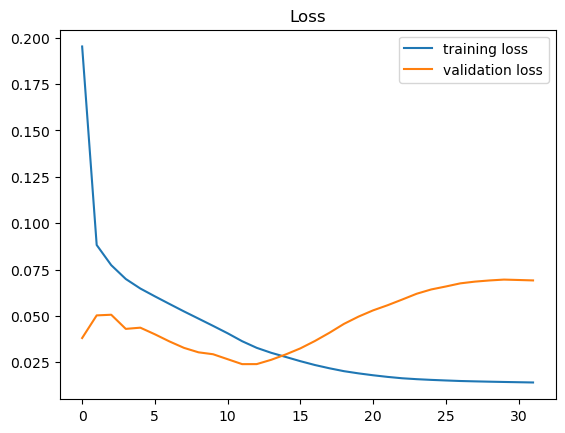

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


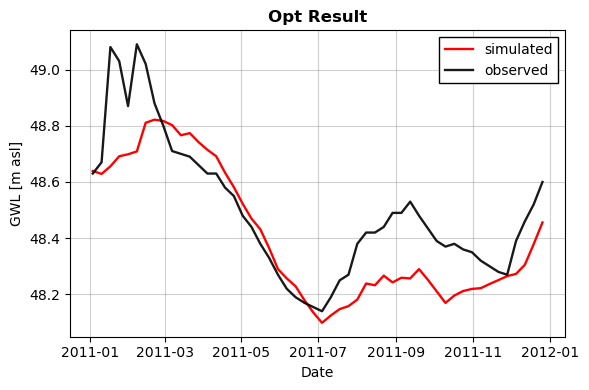

[I 2026-05-18 08:20:36,202] Trial 3 finished with value: 0.023721679434373862 and parameters: {'seq_length': 34}. Best is trial 2 with value: 0.017698687694155158.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100


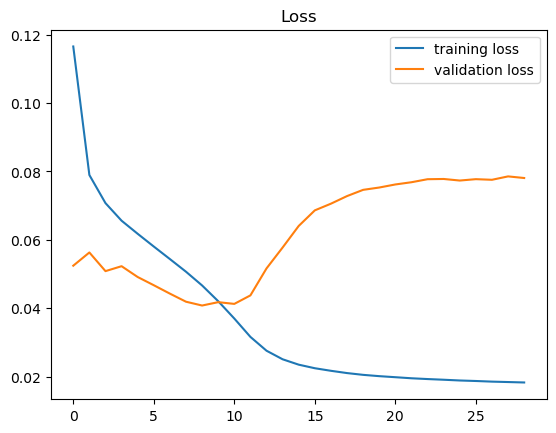

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


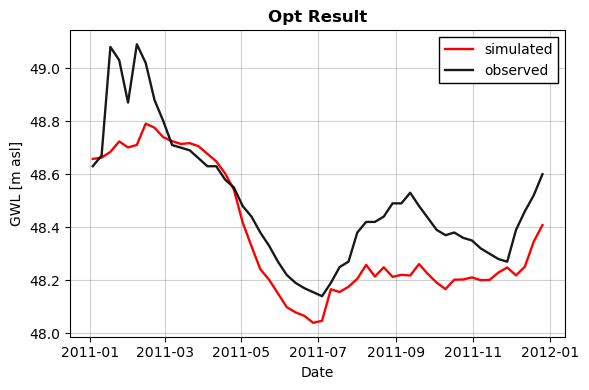

[I 2026-05-18 08:20:55,106] Trial 4 finished with value: 0.027730014019785625 and parameters: {'seq_length': 21}. Best is trial 2 with value: 0.017698687694155158.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100


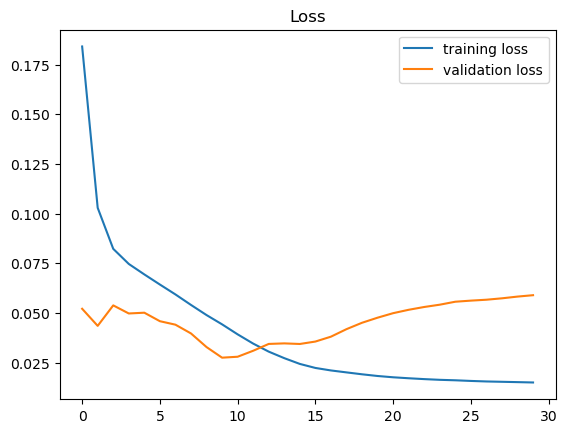

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


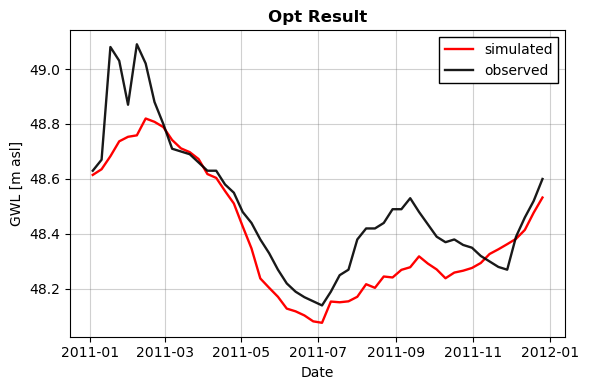

[I 2026-05-18 08:21:15,857] Trial 5 finished with value: 0.019201952191988645 and parameters: {'seq_length': 26}. Best is trial 2 with value: 0.017698687694155158.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100


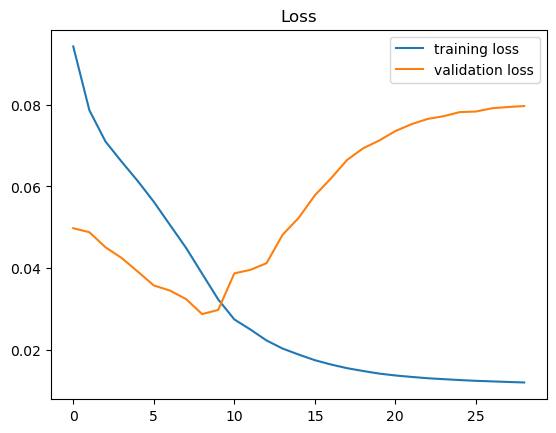

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


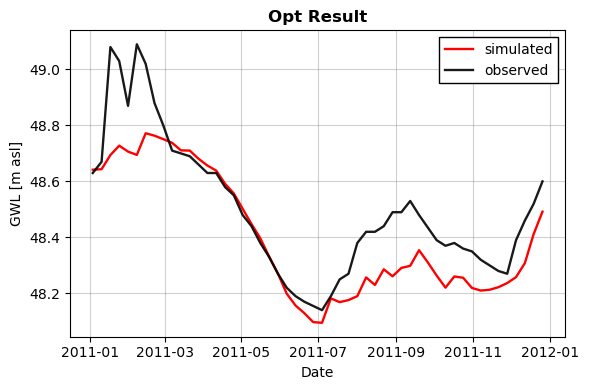

[I 2026-05-18 08:21:38,598] Trial 6 finished with value: 0.019183065358510127 and parameters: {'seq_length': 37}. Best is trial 2 with value: 0.017698687694155158.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100


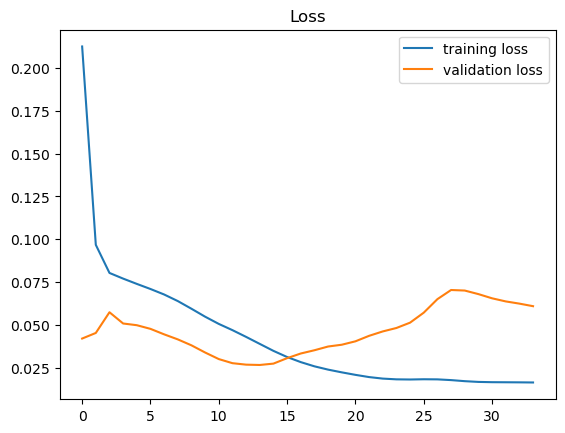

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step


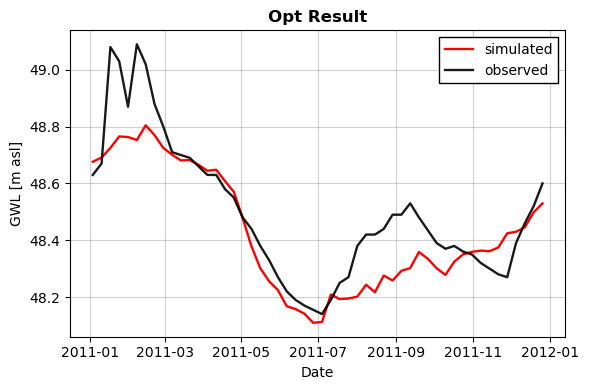

[I 2026-05-18 08:22:01,314] Trial 7 finished with value: 0.015201700651031906 and parameters: {'seq_length': 25}. Best is trial 7 with value: 0.015201700651031906.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100


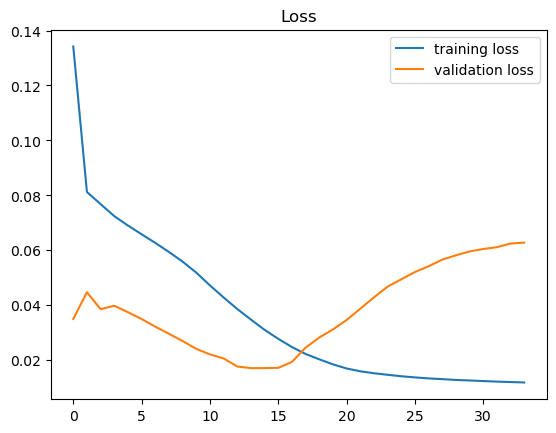

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


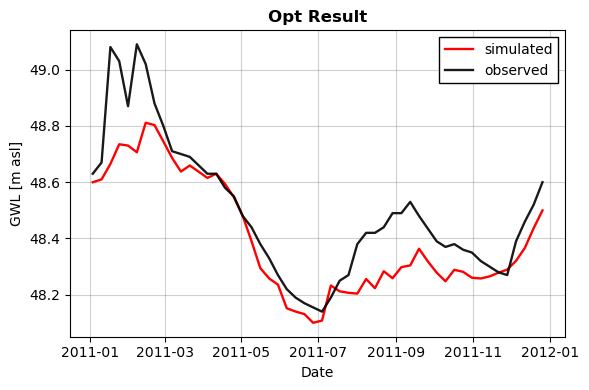

[I 2026-05-18 08:22:27,021] Trial 8 finished with value: 0.017320283131122008 and parameters: {'seq_length': 37}. Best is trial 7 with value: 0.015201700651031906.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100


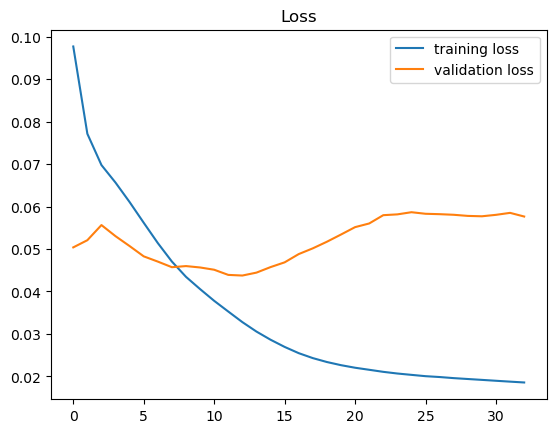

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


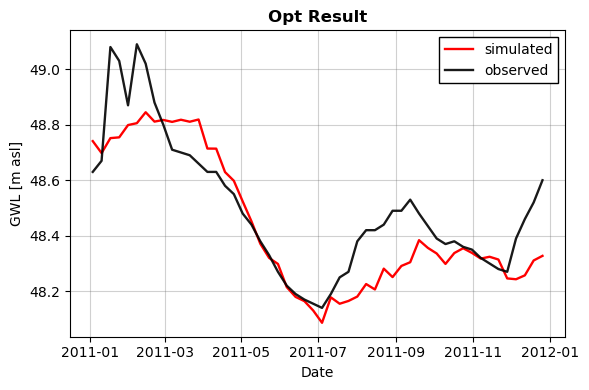

[I 2026-05-18 08:22:47,770] Trial 9 finished with value: 0.017923267591687532 and parameters: {'seq_length': 20}. Best is trial 7 with value: 0.015201700651031906.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100


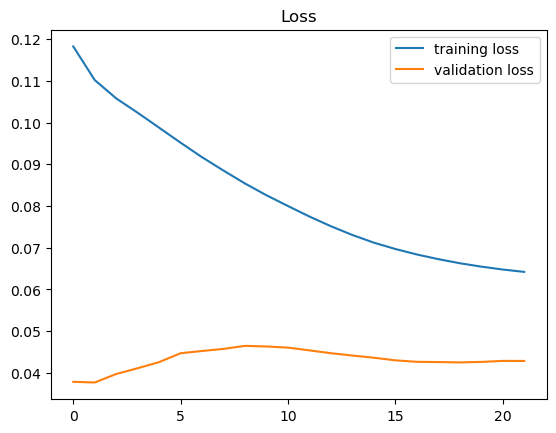

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


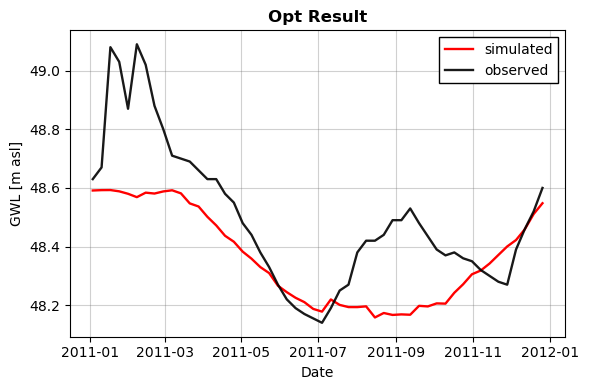

[I 2026-05-18 08:22:56,816] Trial 10 finished with value: 0.04075247869683678 and parameters: {'seq_length': 5}. Best is trial 7 with value: 0.015201700651031906.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100


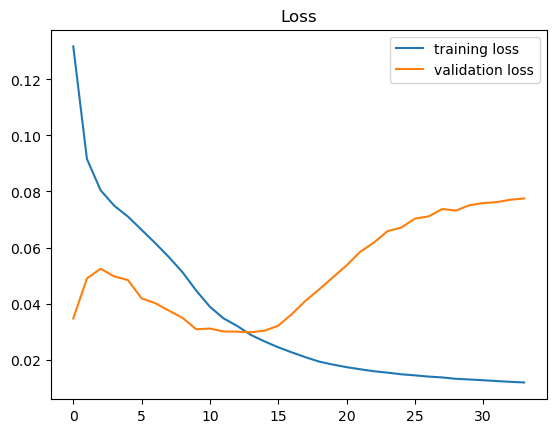

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


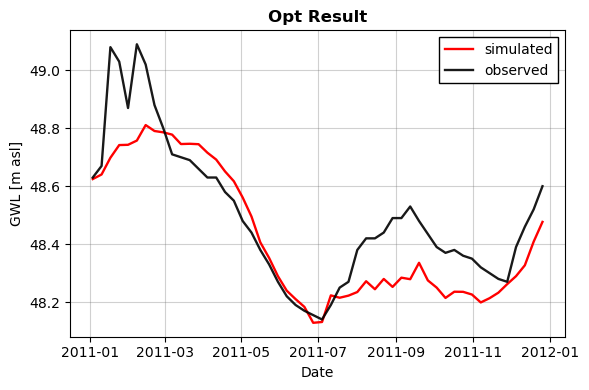

[I 2026-05-18 08:23:23,330] Trial 11 finished with value: 0.018203783723103648 and parameters: {'seq_length': 38}. Best is trial 7 with value: 0.015201700651031906.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100


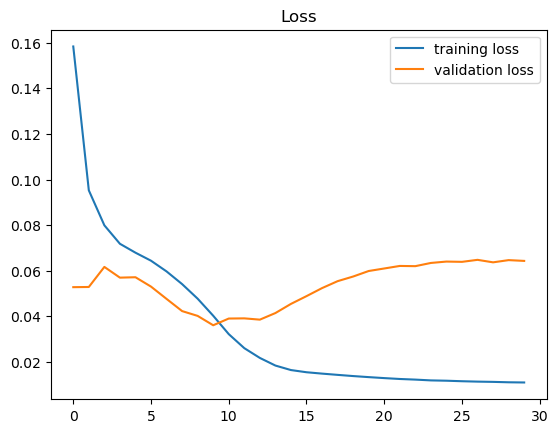

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


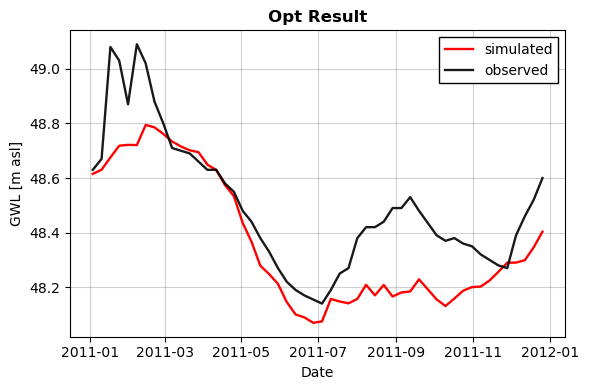

[I 2026-05-18 08:23:49,320] Trial 12 finished with value: 0.030068359267149014 and parameters: {'seq_length': 46}. Best is trial 7 with value: 0.015201700651031906.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100


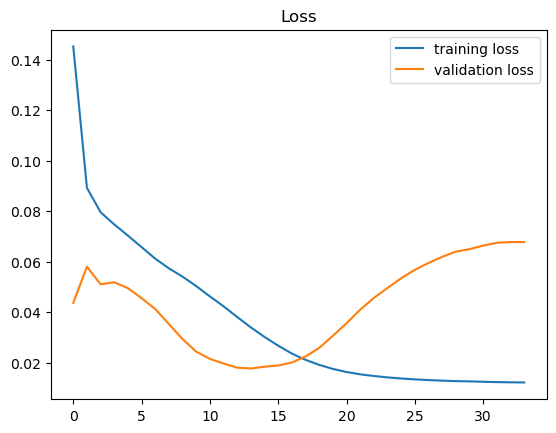

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


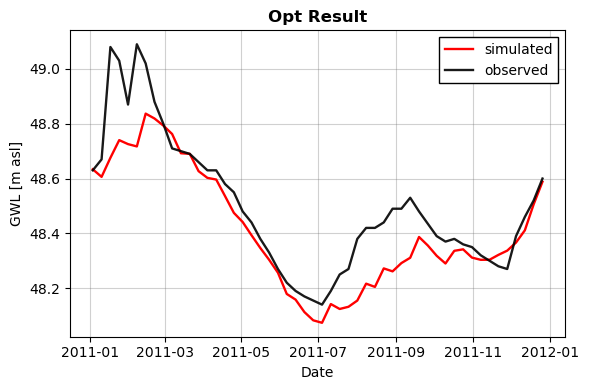

[I 2026-05-18 08:24:12,268] Trial 13 finished with value: 0.016659855867643028 and parameters: {'seq_length': 29}. Best is trial 7 with value: 0.015201700651031906.


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100


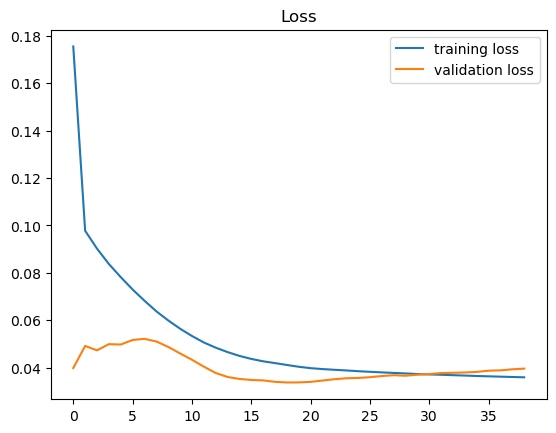

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


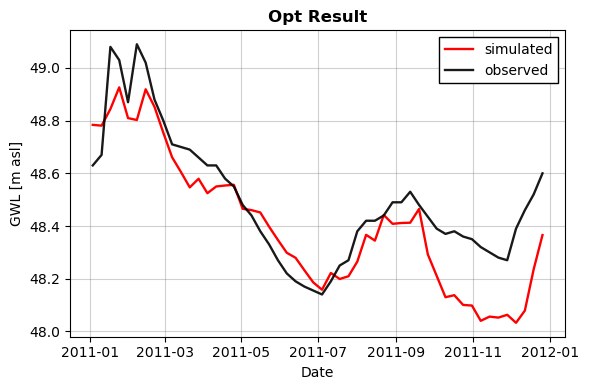

[I 2026-05-18 08:24:31,972] Trial 14 finished with value: 0.02483974091896821 and parameters: {'seq_length': 11}. Best is trial 7 with value: 0.015201700651031906.


0 {'seq_length': 48} 0.026665393286385734
1 {'seq_length': 16} 0.04052014191113437
2 {'seq_length': 22} 0.017698687694155158
3 {'seq_length': 34} 0.023721679434373862
4 {'seq_length': 21} 0.027730014019785625
5 {'seq_length': 26} 0.019201952191988645
6 {'seq_length': 37} 0.019183065358510127
7 {'seq_length': 25} 0.015201700651031906
8 {'seq_length': 37} 0.017320283131122008
9 {'seq_length': 20} 0.017923267591687532
10 {'seq_length': 5} 0.04075247869683678
11 {'seq_length': 38} 0.018203783723103648
12 {'seq_length': 46} 0.030068359267149014
13 {'seq_length': 29} 0.016659855867643028
14 {'seq_length': 11} 0.02483974091896821

Optimale seq_length: 25


In [7]:
def objective(trial):

    seq_length = trial.suggest_int("seq_length", 1, 50)

    score = optfunction(seq_length)

    return score


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)

for trial in study.trials:
    print(trial.number, trial.params, trial.value)

seq_length = study.best_params["seq_length"]
print(f"\nOptimale seq_length: {seq_length}")


Nun wollen wir das Modell mit dem scheinbar optimalen Wert für seq_length trainieren und testen. Hierfür brauchen wir fast den gleichen Code wie in der Funktion (optfunction) oben, nur wenden wir das Modell jetzt auf Testdaten statt Optdaten an:

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100


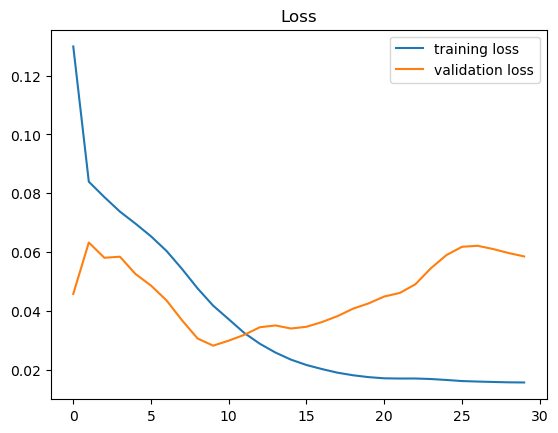

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


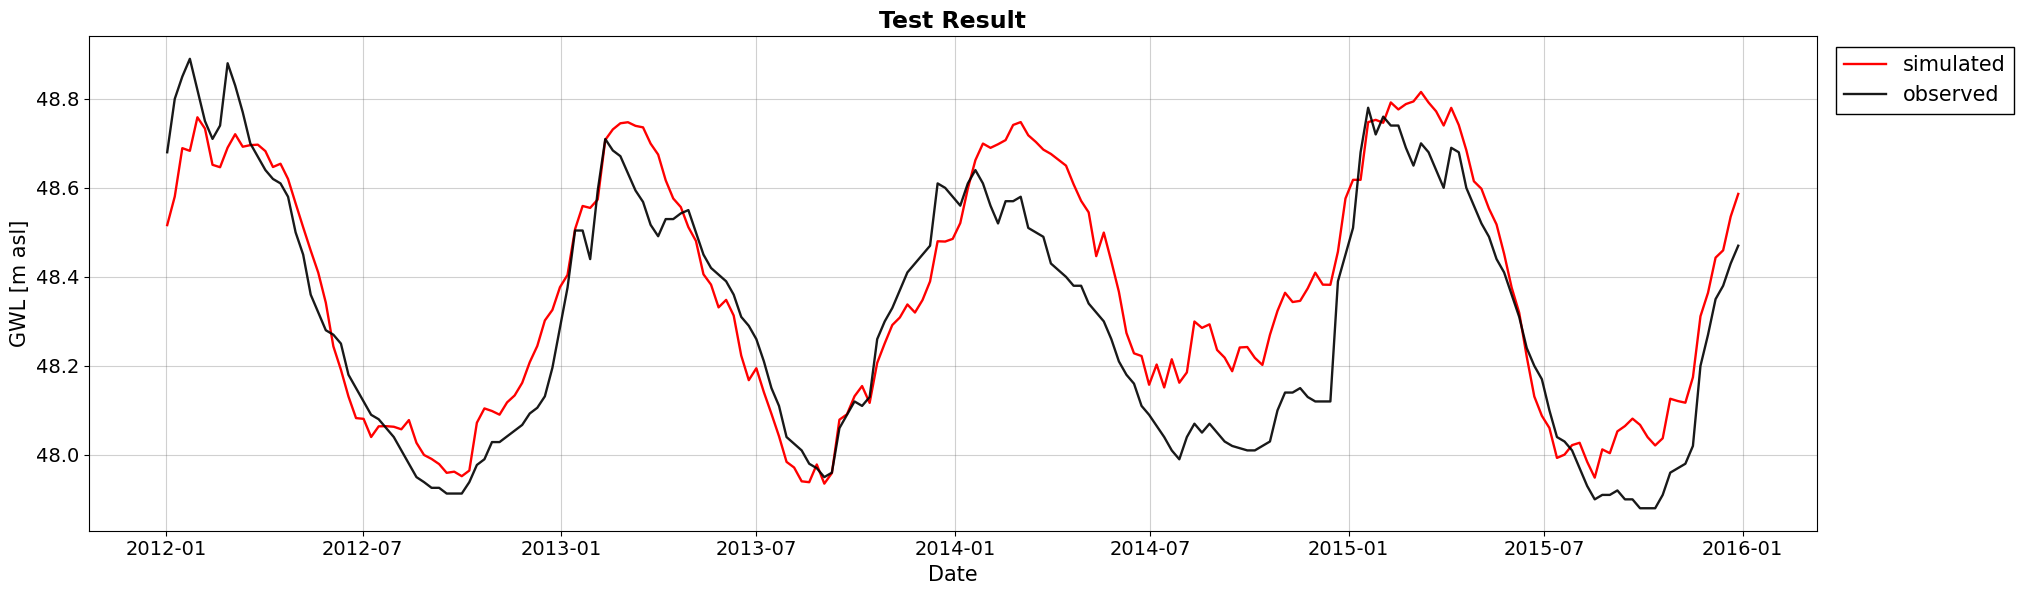

seq_length = 25 weeks


,NSE,RMSE,r,Bias
0,0.805405,0.121852,0.925449,0.061931


In [8]:
#We have already defined seq_length

#%%%%%%%%%%%%%%%%%%%%%%%%%%%
#Now the familiar steps as in the last appointment for time series prediction.
#%%%%%%%%%%%%%%%%%%%%%%%%%%%

#extend with overlap to be able to fill sequence (seq_length) later                                             
StopData_ext = pd.concat([TrainingData.iloc[-seq_length:], StopData], axis=0) #takes last steps of TrainingData and combines it with StopData
TestData_ext = pd.concat([OptData.iloc[-seq_length:], TestData], axis=0) #takes last steps of OptData and combines it with TestData

#create scalers and fit to data data (normalize: *_n):
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(TrainingData) # fit on training data, scale all other parts afterwards

scaler_gwl = MinMaxScaler(feature_range=(-1, 1)) 
scaler_gwl.fit(pd.DataFrame(TrainingData['GWL'])) # fit scaler only on GWL for rescaling later

#scale (transform) data
TrainingData_n = scaler.transform(TrainingData)
StopData_ext_n = scaler.transform(StopData_ext)
TestData_ext_n = scaler.transform(TestData_ext)

#Data to sequences:
X_train,Y_train = make_sequences(np.asarray(TrainingData_n), seq_length)
X_stop,Y_stop = make_sequences(np.asarray(StopData_ext_n), seq_length)
X_test,Y_test = make_sequences(np.asarray(TestData_ext_n), seq_length)


#%%%%%%%%%%%%%%%%%%%%%%%%%%%
#Build and train Model:
#%%%%%%%%%%%%%%%%%%%%%%%%%%%

#set seed
seed(42)
tf.random.set_seed(42)

#build model
inp = Input(shape=(seq_length, X_train.shape[2])) 
lstm = LSTM(32)(inp) 
dense = Dense(30, activation='relu')(lstm) 
output = Dense(1, activation='linear')(dense) 
model = Model(inputs=inp, outputs=output)


#define optimizer
Adam = tf.keras.optimizers.Adam(learning_rate=1E-3, epsilon=1E-3, clipnorm=True)

#compile the model
model.compile(loss='mse', optimizer=Adam, metrics=['mse'])

#define early stopping callback
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=20, restore_best_weights = True)

#train the model
history = model.fit(X_train, Y_train,validation_data=(X_stop, Y_stop), epochs=100, verbose=3,
                    batch_size=32, callbacks=[es])

#plot training loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training loss','validation loss'])
plt.title('Loss')
plt.show()

#%%%%%%%%%%%%%%%%%%%%%%%%%%%
#Testing
#%%%%%%%%%%%%%%%%%%%%%%%%%%%

#test Model with X_test
sim = model.predict(X_test)

#rescale simulated and observed values
sim = scaler_gwl.inverse_transform(sim)  # retransform to original scale
obs = scaler_gwl.inverse_transform(Y_test.reshape(-1,1))

#%%%%%%%%%%%%%%%%%%%%%%%%%%
# Error Metrics
#%%%%%%%%%%%%%%%%%%%%%%%%%%

#Nash-Sutcliffe-Efficiency: NSE
NSE = 1 - ((np.sum((sim-obs) ** 2)) / (np.sum((obs - np.mean(obs)) ** 2)))

#Root Mean Squared Error
RMSE =  np.sqrt(np.mean((sim-obs) ** 2))

#Pearson r
r = stats.pearsonr(sim[:,0], obs[:,0])
r = r[0] #r

#Bias
Bias = np.mean(sim-obs)

scores = pd.DataFrame(np.array([[NSE, RMSE, r, Bias]]),
                      columns=['NSE','RMSE','r','Bias'])

#%%%%%%%%%%%%%%%%%%%%%%%%%%
# Plot the measured and simulated Timeseries
#%%%%%%%%%%%%%%%%%%%%%%%%%%

#Plot testset Simulation
plt.figure(figsize=(20,6))
plt.plot(TestData.index, sim, 'r', label ="simulated", linewidth = 1.7)
plt.plot(TestData.index, obs, 'k', label ="observed", linewidth=1.7,alpha=0.9)

plt.title("Test Result", size=17,fontweight = 'bold')
plt.ylabel('GWL [m asl]', size=15)
plt.xlabel('Date',size=15)
plt.legend(fontsize=15,bbox_to_anchor=(1.12, 1),loc='upper right',fancybox = False, framealpha = 1, edgecolor = 'k')
plt.tight_layout()
plt.grid(visible=True, which='major', color='#666666', alpha = 0.3, linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

print("seq_length = {:.0f} weeks".format(seq_length))
scores.head()

### Aufgabe 1: zusätzlichen Hyperparameter optimieren

Wir möchten neben seq_length nun auch die Anzahl der LSTm units im LSTM Layer optimieren. Der Parameter soll *n* heißen.

Ändere den obigen Code so, dass beide Parameter optimiert werden. nutze dafür folende Anleitung:  
* Füge *n* der Funktion *optfunction* als Input parameter hinzu (gnau wie seq_length):
```python
    def optfunction(seq_length,n): 
```
* Füge *n* an entsprechener Stelle im LSTM Layer ein
```python
    ...(units=n)... 
```
* Optimiere zusätzlich *n* für einen Wertebereich von 8 bis 128 in 8er Schritten. Hierfür musst du *n* auch der Funktion *objective* hinzufügen:
* 
```python
def objective(trial):

    A = trial.suggest_int("A", AMin,AMax)
    B = trial.suggest_int("B", BMin, BMax, step= steps)

    score = optfunction(A, B)
    
    return score

Tipp: Entweder du änderst direkt den Code den du oberhalb findest (dann am besten das Notebook als Kopie abspeichern), oder kopiere dir den Code nach unten und erstellst neue Zellen. 

### Einfaches Ensemble

Alle ANN werden mit (quasi)zufälligen Werten der Gewichte initialisiert. Um das Modell reproduzierbar zu halten, setzen wir immer den random seed vor jedem Durchlauf. Dies können wir aber auch nutzen um ein Ensemble zu erstellen, welches uns zeigt wie stark das Ergebnis vom random seed abhängt. Anstatt nun also immer den gleichen seed zu wählen, definieren wir mehrere Modelle mit unterschiedlichen Initialisierungen. 

Zunächst definieren wir den Array *sim_all*, in den die Ergebnisse aller Durchläufe jeweils als Spalte eingefügt werden sollen. Anschließend schreiben wir eine Schleife, innerhalb der das Modell in Abhängigkeit des jeweiligen Seeds aufgebaut, trainiert und getestet wird. Die Ergebnisse der Vorhersagen speichern wir in am Ende jedes Duschlaufs in *sim_all*. 

0


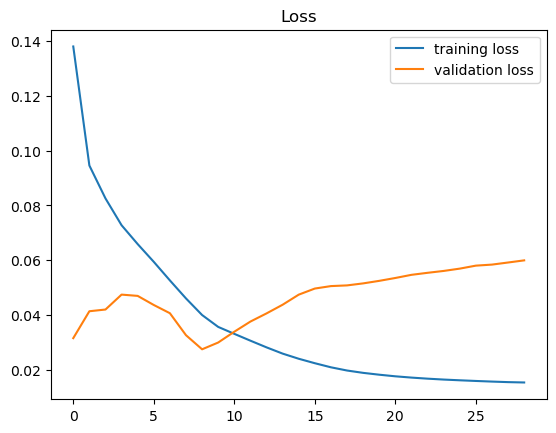

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1


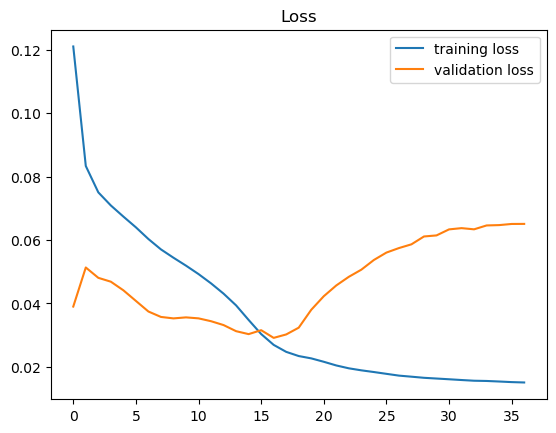

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2


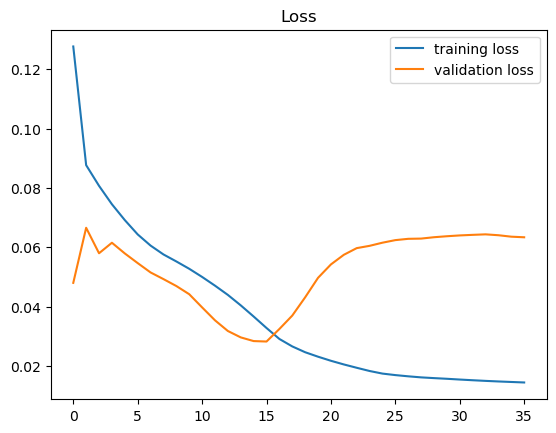

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
3


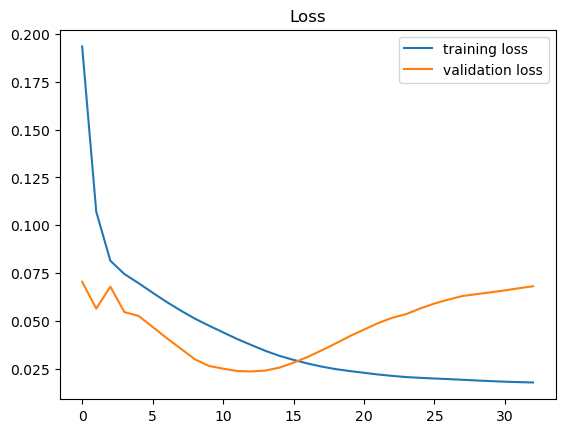

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4


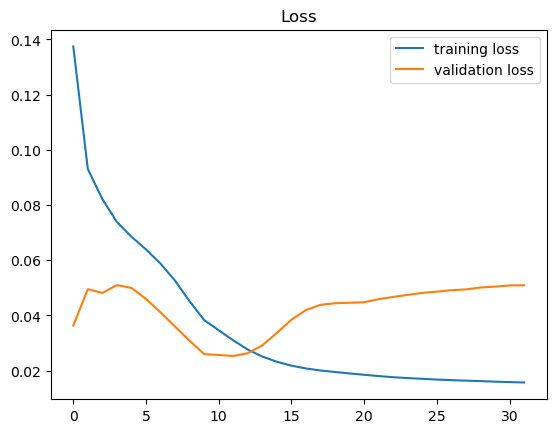

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [16]:
seeds=5
sim_all = np.zeros((Y_test.shape[0],seeds)) #This is called preallocation, 

for ini in range(seeds): 
    print(ini)
    seed(42+ini)
    tf.random.set_seed(42+ini)

    #build model
    inp = tf.keras.Input(shape=(seq_length, X_train.shape[2])) 
    lstm = tf.keras.layers.LSTM(32)(inp) 
    dense = tf.keras.layers.Dense(30, activation='relu')(lstm) 
    output = tf.keras.layers.Dense(1, activation='linear')(dense) 
    model = tf.keras.Model(inputs=inp, outputs=output)

    #define optimizer for LSTM
    Adam = tf.keras.optimizers.Adam(learning_rate=1E-3, epsilon=1E-3, clipnorm=True)

    #compile the model
    model.compile(loss='mse', optimizer=Adam, metrics=['mse'])

    #define early stopping callback
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=20, restore_best_weights = True)

    #train the model
    history = model.fit(X_train, Y_train,validation_data=(X_stop, Y_stop), epochs=100, verbose=0,
                        batch_size=32, callbacks=[es])

    #plot training loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(['training loss','validation loss'])
    plt.title('Loss')
    plt.show()

    #%%%%%%%%%%%%%%%%%%%%%%%%%%%
    #Test
    #%%%%%%%%%%%%%%%%%%%%%%%%%%%

    #test model with X_test
    sim = model.predict(X_test)

    #rescale simulated and observed values
    sim = scaler_gwl.inverse_transform(sim)  # retransform to original scale
    obs = scaler_gwl.inverse_transform(Y_test.reshape(-1,1))

    sim_all[:,ini] = sim.reshape(-1,) #here insert sim of each pass into the ini'th column of sim_all

Nun können wir den Ensemble-Median (Ensemble-Vorhersage) berechnen, Fehlermetriken für unsere Ensemble-Vorhersage ermitteln und die Vorhersagen der einzelnen Ensemble-Mitglieder sowie die Median-Vorhersage plotten. 

   NSE_median  RMSE_median  r_median  Bias_median   Std_Dev
0    0.878418     0.096317   0.94888     0.040771  0.037989


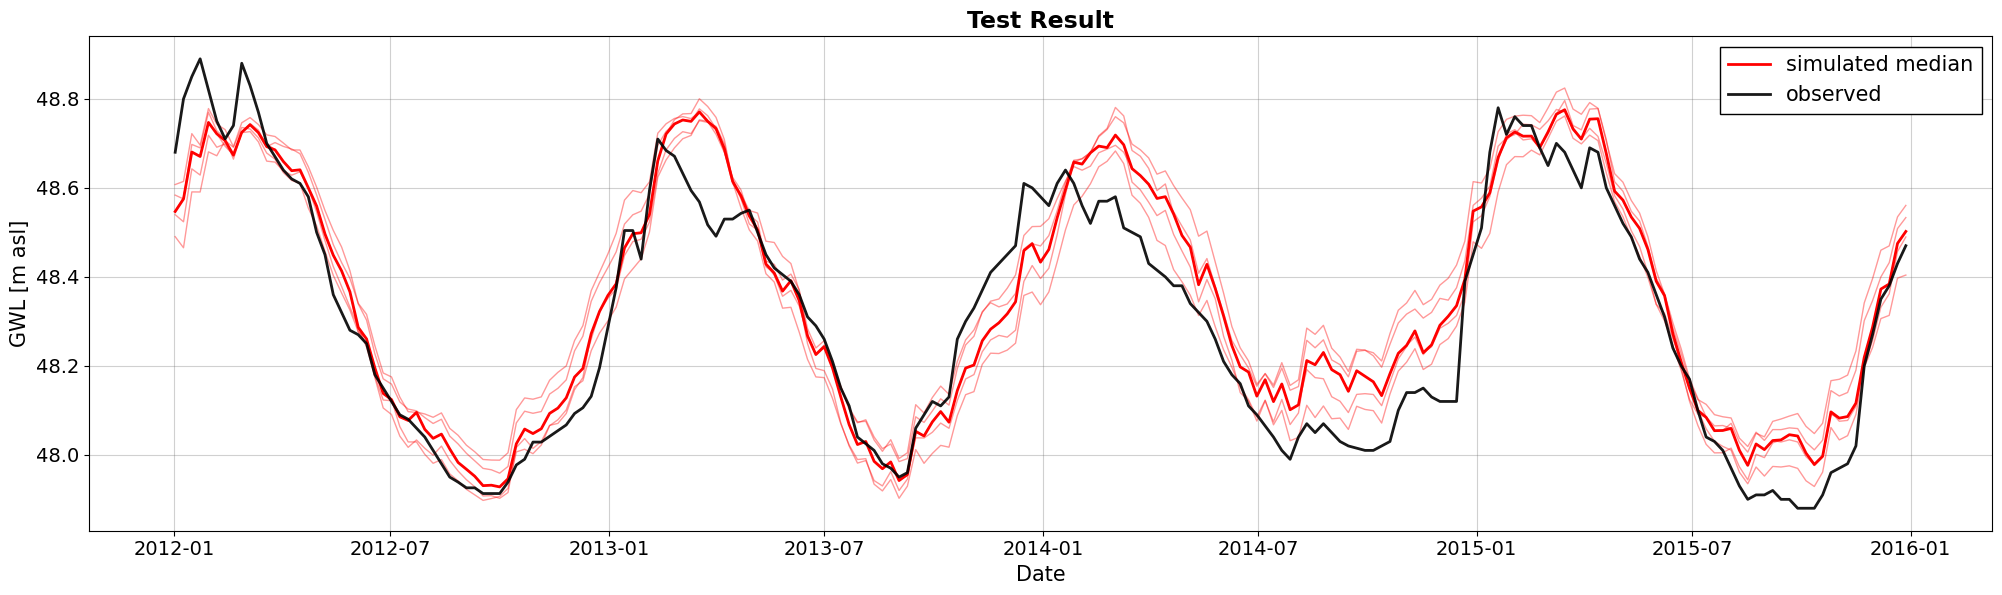

In [20]:
sim_median = np.median(sim_all,axis = 1).reshape(-1,1) #We calculate the median value of the ensemble
std_predictions = np.std(sim_all, axis=1).reshape(-1, 1) #We calculate the standard deviation of the ensemble

#Nash-Sutcliffe-Efficiency: NSE
NSE_median = 1 - ((np.sum((sim_median-obs) ** 2)) / (np.sum((obs - np.mean(obs)) ** 2)))
#Root Mean Squared Error
RMSE_median =  np.sqrt(np.mean((sim_median-obs) ** 2))
#Pearson r
r_median = stats.pearsonr(sim_median[:,0], obs[:,0])
r_median = r_median[0] #r
#Bias
Bias_median = np.mean(sim_median-obs)
#Std
std_median = np.mean(std_predictions)
scores_median = pd.DataFrame(np.array([[NSE_median, RMSE_median, r_median, Bias_median, std_median]]),
                      columns=['NSE_median','RMSE_median','r_median','Bias_median','Std_Dev'])

print(scores_median)

#Plot testset Simulation
plt.figure(figsize=(20,6))

for i in range(seeds):
    plt.plot(TestData.index, sim_all[:,i], 'r', label = None, linewidth = 1, alpha = 0.4)

plt.plot(TestData.index, sim_median, 'r', label ="simulated median", linewidth = 2)
plt.plot(TestData.index, obs, 'k', label ="observed", linewidth=2,alpha=0.9)

plt.title("Test Result", size=17,fontweight = 'bold')
plt.ylabel('GWL [m asl]', size=15)
plt.xlabel('Date',size=15)
plt.legend(fontsize=15,fancybox = False, framealpha = 1, edgecolor = 'k')
plt.tight_layout()
plt.grid(visible=True, which='major', color='#666666', alpha = 0.3, linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()